In [1]:
# ============================================================
# CELL 1
# IMPORT LIBRARIES
# ENSEMBLE INFERENCE NOTEBOOK
# ============================================================

import os

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from tqdm import tqdm

# ============================================================
# PYTORCH
# ============================================================

import torch

import torch.nn as nn

from torch.utils.data import DataLoader

# ============================================================
# TORCHVISION
# ============================================================

from torchvision import datasets

from torchvision import transforms

from torchvision import models

# ============================================================
# SKLEARN METRICS
# ============================================================

from sklearn.metrics import (

    accuracy_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    auc
)

from sklearn.preprocessing import label_binarize

# ============================================================
# IGNORE WARNINGS
# ============================================================

warnings.filterwarnings("ignore")

print("="*60)

print("All Libraries Imported Successfully!")

print("="*60)

All Libraries Imported Successfully!


In [2]:
# ============================================================
# CELL 2
# DEVICE CONFIGURATION
# ============================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("="*60)

print(f"Using Device: {device}")

print("="*60)

if torch.cuda.is_available():

    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    print(f"CUDA Version: {torch.version.cuda}")

    print(f"GPU Count: {torch.cuda.device_count()}")

    print(

        f"GPU Memory: "
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )

print("="*60)

Using Device: cuda
GPU Name: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 12.8
GPU Count: 1
GPU Memory: 7.96 GB


In [3]:
# ============================================================
# CELL 3
# CONFIGURATION & MODEL PATHS
# ============================================================

# ============================================================
# TEST DATASET PATH
# ============================================================

test_dir = "../dataset/enhanced_test"

# ============================================================
# MODEL PATHS
# ============================================================

EFFICIENTNET_MODEL_PATH = (

    "../models/efficientnet/"
    "best_efficientnet_b2.pth"
)

DENSENET_MODEL_PATH = (

    "../models/densenet121/"
    "best_densenet121_phase2.pth"
)

# ============================================================
# IMAGE CONFIGURATION
# ============================================================

IMAGE_SIZE = 300

BATCH_SIZE = 32

NUM_CLASSES = 5

# ============================================================
# ENSEMBLE WEIGHTS
# ============================================================

DENSENET_WEIGHT = 0.6

EFFICIENTNET_WEIGHT = 0.4

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [

    "No DR",

    "Mild",

    "Moderate",

    "Severe",

    "Proliferative DR"
]

print("="*60)

print("Configuration Loaded Successfully!")

print("="*60)

print(f"Test Dataset Path : {test_dir}")

print("="*60)

print("Model Paths")

print("="*60)

print(f"EfficientNetB2 : {EFFICIENTNET_MODEL_PATH}")

print(f"DenseNet121    : {DENSENET_MODEL_PATH}")

print("="*60)

print("Ensemble Weights")

print("="*60)

print(f"DenseNet121 Weight   : {DENSENET_WEIGHT}")

print(f"EfficientNet Weight  : {EFFICIENTNET_WEIGHT}")

print("="*60)

Configuration Loaded Successfully!
Test Dataset Path : ../dataset/enhanced_test
Model Paths
EfficientNetB2 : ../models/efficientnet/best_efficientnet_b2.pth
DenseNet121    : ../models/densenet121/best_densenet121_phase2.pth
Ensemble Weights
DenseNet121 Weight   : 0.6
EfficientNet Weight  : 0.4


In [4]:
# ============================================================
# CELL 4
# IMAGE TRANSFORMS & TEST DATALOADER
# ============================================================

# ============================================================
# TEST TRANSFORMS
# ============================================================

test_transforms = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# LOAD TEST DATASET
# ============================================================

test_dataset = datasets.ImageFolder(

    root=test_dir,

    transform=test_transforms
)

# ============================================================
# CREATE TEST DATALOADER
# ============================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

print("="*60)

print("Test Dataset & DataLoader Ready!")

print("="*60)

print(f"Test Images  : {len(test_dataset)}")

print(f"Test Batches : {len(test_loader)}")

print("="*60)

Test Dataset & DataLoader Ready!
Test Images  : 225
Test Batches : 8


In [5]:
# ============================================================
# CELL 5
# LOAD EFFICIENTNETB2 MODEL
# ============================================================

# ============================================================
# CREATE EFFICIENTNETB2
# ============================================================

efficientnet_model = models.efficientnet_b2(

    weights=None
)

# ============================================================
# MODIFY CLASSIFIER
# ============================================================

in_features = (

    efficientnet_model.classifier[1]
    .in_features
)

efficientnet_model.classifier = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(

        in_features,

        NUM_CLASSES
    )
)

# ============================================================
# LOAD TRAINED WEIGHTS
# ============================================================

efficientnet_model.load_state_dict(

    torch.load(

        EFFICIENTNET_MODEL_PATH,

        map_location=device
    )
)

# ============================================================
# MOVE TO DEVICE
# ============================================================

efficientnet_model = efficientnet_model.to(device)

# ============================================================
# EVALUATION MODE
# ============================================================

efficientnet_model.eval()

print("="*60)

print("EfficientNetB2 Loaded Successfully!")

print("="*60)

print(efficientnet_model.classifier)

print("="*60)

EfficientNetB2 Loaded Successfully!
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1408, out_features=5, bias=True)
)


In [6]:
# ============================================================
# CELL 6
# LOAD DENSENET121 MODEL
# ============================================================

# ============================================================
# CREATE DENSENET121
# ============================================================

densenet_model = models.densenet121(

    weights=None
)

# ============================================================
# GET INPUT FEATURES
# ============================================================

in_features = (

    densenet_model.classifier
    .in_features
)

# ============================================================
# MODIFY CLASSIFIER
# ============================================================

densenet_model.classifier = nn.Sequential(

    nn.Linear(

        in_features,

        512
    ),

    nn.ReLU(),

    nn.Dropout(0.4),

    nn.Linear(

        512,

        256
    ),

    nn.ReLU(),

    nn.Dropout(0.3),

    nn.Linear(

        256,

        NUM_CLASSES
    )
)

# ============================================================
# LOAD TRAINED WEIGHTS
# ============================================================

densenet_model.load_state_dict(

    torch.load(

        DENSENET_MODEL_PATH,

        map_location=device
    )
)

# ============================================================
# MOVE TO DEVICE
# ============================================================

densenet_model = densenet_model.to(device)

# ============================================================
# EVALUATION MODE
# ============================================================

densenet_model.eval()

print("="*60)

print("DenseNet121 Loaded Successfully!")

print("="*60)

print(densenet_model.classifier)

print("="*60)

DenseNet121 Loaded Successfully!
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=5, bias=True)
)


In [7]:
# ============================================================
# CELL 7
# ENSEMBLE INFERENCE
# WEIGHTED SOFT VOTING
# ============================================================

# ============================================================
# STORE RESULTS
# ============================================================

true_labels = []

ensemble_predictions = []

ensemble_probabilities = []

# ============================================================
# EVALUATION MODE
# ============================================================

efficientnet_model.eval()

densenet_model.eval()

# ============================================================
# DISABLE GRADIENTS
# ============================================================

with torch.no_grad():

    progress_bar = tqdm(

        test_loader,

        desc="Running Ensemble Inference"
    )

    for images, labels in progress_bar:

        # ====================================================
        # MOVE TO DEVICE
        # ====================================================

        images = images.to(device)

        labels = labels.to(device)

        # ====================================================
        # EFFICIENTNET OUTPUTS
        # ====================================================

        efficientnet_outputs = (

            efficientnet_model(images)
        )

        efficientnet_probs = torch.softmax(

            efficientnet_outputs,

            dim=1
        )

        # ====================================================
        # DENSENET OUTPUTS
        # ====================================================

        densenet_outputs = (

            densenet_model(images)
        )

        densenet_probs = torch.softmax(

            densenet_outputs,

            dim=1
        )

        # ====================================================
        # WEIGHTED ENSEMBLE
        # ====================================================

        final_probs = (

            (DENSENET_WEIGHT * densenet_probs)

            +

            (EFFICIENTNET_WEIGHT * efficientnet_probs)
        )

        # ====================================================
        # FINAL PREDICTIONS
        # ====================================================

        _, preds = torch.max(

            final_probs,

            1
        )

        # ====================================================
        # STORE LABELS
        # ====================================================

        true_labels.extend(

            labels.cpu().numpy()
        )

        # ====================================================
        # STORE PREDICTIONS
        # ====================================================

        ensemble_predictions.extend(

            preds.cpu().numpy()
        )

        # ====================================================
        # STORE PROBABILITIES
        # ====================================================

        ensemble_probabilities.extend(

            final_probs.cpu().numpy()
        )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

ensemble_probabilities = np.array(

    ensemble_probabilities
)

# ============================================================
# CALCULATE ACCURACY
# ============================================================

ensemble_accuracy = accuracy_score(

    true_labels,

    ensemble_predictions
) * 100

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "="*60)

print("ENSEMBLE INFERENCE RESULTS")

print("="*60)

print(

    f"Ensemble Accuracy : "
    f"{ensemble_accuracy:.2f}%"
)

print("="*60)

Running Ensemble Inference: 100%|██████████| 8/8 [00:11<00:00,  1.45s/it]


ENSEMBLE INFERENCE RESULTS
Ensemble Accuracy : 70.22%


In [8]:
# ============================================================
# CELL 8
# ENSEMBLE CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*60)

print("ENSEMBLE CLASSIFICATION REPORT")

print("="*60)

print(

    classification_report(

        true_labels,

        ensemble_predictions,

        target_names=class_names
    )
)


ENSEMBLE CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           No DR       0.86      0.96      0.91        45
            Mild       0.69      0.64      0.67        45
        Moderate       0.59      0.49      0.54        45
          Severe       0.65      0.82      0.73        45
Proliferative DR       0.69      0.60      0.64        45

        accuracy                           0.70       225
       macro avg       0.70      0.70      0.70       225
    weighted avg       0.70      0.70      0.70       225



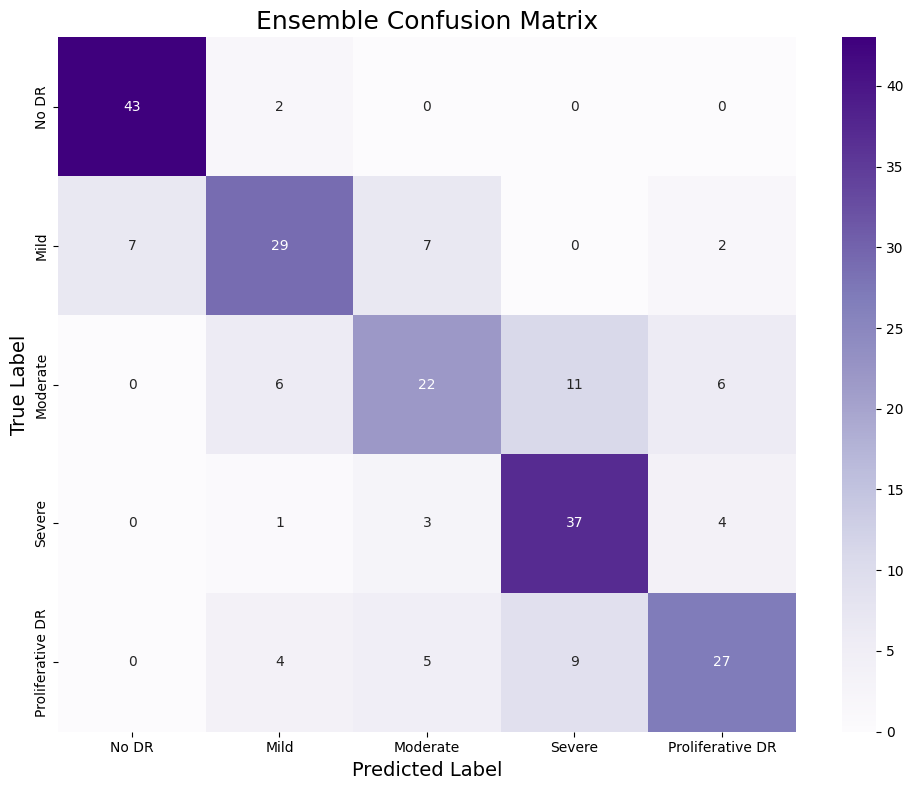

In [9]:
# ============================================================
# CELL 9
# ENSEMBLE CONFUSION MATRIX
# ============================================================

ensemble_cm = confusion_matrix(

    true_labels,

    ensemble_predictions
)

# ============================================================
# CREATE FIGURE
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(

    ensemble_cm,

    annot=True,

    fmt='d',

    cmap='Purples',

    xticklabels=class_names,

    yticklabels=class_names
)

# ============================================================
# LABELS
# ============================================================

plt.title(

    "Ensemble Confusion Matrix",

    fontsize=18
)

plt.xlabel(

    "Predicted Label",

    fontsize=14
)

plt.ylabel(

    "True Label",

    fontsize=14
)

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# CELL 10
# FINAL ENSEMBLE SUMMARY
# ============================================================

print("\n" + "="*70)

print("FINAL ENSEMBLE RESULTS")

print("="*70)

print(f"EfficientNetB2 Accuracy : {68.44:.2f}%")

print(f"DenseNet121 Accuracy    : {68.00:.2f}%")

print(f"Ensemble Accuracy       : {ensemble_accuracy:.2f}%")

print("="*70)

print("ENSEMBLE CONFIGURATION")

print("="*70)

print(f"DenseNet121 Weight      : {DENSENET_WEIGHT}")

print(f"EfficientNetB2 Weight   : {EFFICIENTNET_WEIGHT}")

print("="*70)

print("BEST MODEL CHARACTERISTICS")

print("="*70)

print("DenseNet121  : Better lesion discrimination")

print("EfficientNet : Better global retinal understanding")

print("Ensemble     : Best balanced performance")

print("="*70)

print("FINAL STATUS")

print("="*70)

print("RetaniaScan-AI Ensemble System Ready!")

print("="*70)


FINAL ENSEMBLE RESULTS
EfficientNetB2 Accuracy : 68.44%
DenseNet121 Accuracy    : 68.00%
Ensemble Accuracy       : 70.22%
ENSEMBLE CONFIGURATION
DenseNet121 Weight      : 0.6
EfficientNetB2 Weight   : 0.4
BEST MODEL CHARACTERISTICS
DenseNet121  : Better lesion discrimination
EfficientNet : Better global retinal understanding
Ensemble     : Best balanced performance
FINAL STATUS
RetaniaScan-AI Ensemble System Ready!
